In [ ]:
# Import and Read the data

In [2]:
import mne

In [3]:
# Read eeg data

raw = mne.io.read_raw_eeglab(
    "sub-010_ses-01_task-experiment_run-01_eeg.set", 
    preload=False, 
    eog=['HEOGL', 'HEOGR', 'VEOGU', 'VEOGL'])
print(raw)

Reading /home/cindy/BHSFinal/sub10_sess1.fdt
<RawEEGLAB | sub10_sess1.fdt, 128 x 4958828 (4842.6 s), ~142 KiB, data not loaded>


/tmp/ipykernel_2266/2035522763.py:3: RuntimeWarning: Estimated head radius (0.0 cm) is below the 3rd percentile for infant head size. Check if the montage_units argument is correct (the default is "mm", but your channel positions may be in different units).
  raw = mne.io.read_raw_eeglab(
/tmp/ipykernel_2266/2035522763.py:3: RuntimeWarning: Not setting positions of 4 eog channels found in montage:
['HEOGR', 'HEOGL', 'VEOGU', 'VEOGL']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_eeglab(


In [4]:
# check for data's information
raw.info

<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fpz, Fp2, F7, F3, Fz, F4, F8, FC5, FC1, FC2, FC6, M1, T7, ...
 chs: 124 EEG, 4 EOG
 custom_ref_applied: False
 dig: 127 items (3 Cardinal, 124 EEG)
 highpass: 0.0 Hz
 lowpass: 512.0 Hz
 meas_date: unspecified
 nchan: 128
 projs: []
 sfreq: 1024.0 Hz
>

In [4]:
# Check for total channel
print(raw.ch_names)
len(raw.ch_names)

['Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6', 'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6', 'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'O2', 'HEOGR', 'AF7', 'AF3', 'AF4', 'AF8', 'F5', 'F1', 'F2', 'F6', 'FC3', 'FCz', 'FC4', 'C5', 'C1', 'C2', 'C6', 'CP3', 'CP4', 'P5', 'P1', 'P2', 'P6', 'HEOGL', 'PO3', 'PO4', 'VEOGU', 'FT7', 'FT8', 'TP7', 'TP8', 'PO7', 'PO8', 'VEOGL', 'FT9', 'FT10', 'TPP9h', 'TPP10h', 'PO9', 'PO10', 'P9', 'P10', 'AFF1', 'AFz', 'AFF2', 'FFC5h', 'FFC3h', 'FFC4h', 'FFC6h', 'FCC5h', 'FCC3h', 'FCC4h', 'FCC6h', 'CCP5h', 'CCP3h', 'CCP4h', 'CCP6h', 'CPP5h', 'CPP3h', 'CPP4h', 'CPP6h', 'PPO1', 'PPO2', 'I1', 'Iz', 'I2', 'AFp3h', 'AFp4h', 'AFF5h', 'AFF6h', 'FFT7h', 'FFC1h', 'FFC2h', 'FFT8h', 'FTT9h', 'FTT7h', 'FCC1h', 'FCC2h', 'FTT8h', 'FTT10h', 'TTP7h', 'CCP1h', 'CCP2h', 'TTP8h', 'TPP7h', 'CPP1h', 'CPP2h', 'TPP8h', 'PPO9h', 'PPO5h', 'PPO6h', 'PPO10h', 'POO9h', 'POO3h', 'POO4h', 'POO10h', 'OI1h', 'OI2h']


128

In [5]:
# Sampling frequency
raw.info["sfreq"]

1024.0

In [5]:
# initial psd
initial_psd = raw.compute_psd(fmin = 0,fmax=100, n_fft=2048)

Effective window size : 2.000 (s)


Plotting power spectral density (dB=True).


/tmp/ipykernel_2266/35496246.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  initial_psd.plot(spatial_colors=True)
/home/cindy/miniconda3/lib/python3.13/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


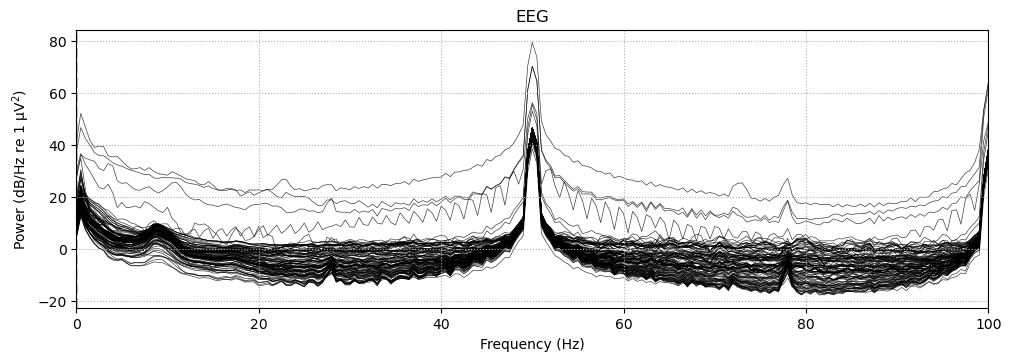

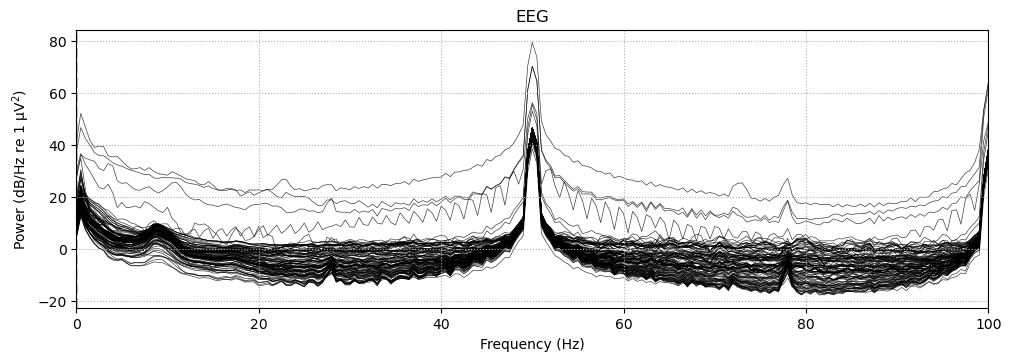

In [6]:
initial_psd.plot(spatial_colors=True)

In [ ]:
# Plot the raw data
raw.plot(duration=1, n_channels=5, start = 500 )

In [ ]:
# Set montage

In [ ]:
# Check for montage
montage=raw.get_montage()
print(montage)

# montage already present, no need to set anymore

In [ ]:
# The channel for montage
print(len(montage.ch_names))

In [ ]:
# Plot 2D montage
montage.plot(kind="topomap", show_names=True)

# show nothing? instead showing duplicate electrode?

In [ ]:
# Plot 3D
montage.plot(kind="3d")

# show nothing? instead showing duplicate electrode?

In [ ]:
# Try run for the position, it shows 0.0.0 for all channels location
# Which means the montage is not set in the original data

print(montage.get_positions())

In [ ]:
# More evidence proves that montage is not set (1)

montage.get_positions()['ch_pos']

In [ ]:
# More evidence proves that montage is not set (2)

ch_pos = montage.get_positions()['ch_pos']

for name, pos in list(ch_pos.items())[:10]:
    print(name, pos)

In [ ]:
# More evidence proves that montage is not set (3)

montage = raw.get_montage()

ch_pos = montage.get_positions()['ch_pos']

for ch in ['Fp1', 'Fpz', 'Fp2', 'Fz', 'Cz']:
    print(ch, ch_pos[ch])

In [ ]:
# Last solution
# Since the channel is close to extended 10-10 system
# just use that for montage
# For roughly montage location set



In [8]:
# set montage using 10-10 system
montage = mne.channels.make_standard_montage("standard_1005")

raw.set_montage(montage, on_missing="ignore")

<RawEEGLAB | sub10_sess1.fdt, 128 x 4958828 (4842.6 s), ~143 KiB, data not loaded>

In [6]:
# Check whether montage is successfully set

print(raw.get_montage().get_positions()['ch_pos']['Fp1'])

# Result shows yes

[-0.03090259  0.11458518  0.02786657]


In [ ]:
# Plot 2D

fig = raw.plot_sensors(ch_type='eeg', show_names=True, show=False)
fig.savefig("eeg_plots/03_sensor_positions.png", dpi=100, bbox_inches='tight')
plt.close(fig)
print("Saved: eeg_plots/03_sensor_positions.png")

In [ ]:
# Plot 3D
# montage.plot(kind="3d")

In [9]:
# check for the new montage information
print(len(montage.ch_names))

# all complete montage in 10-10 format
# But already matched with our own dataset

343


In [ ]:
# Check for bad channels

In [7]:
import matplotlib.pyplot as plt
import numpy as np

In [8]:
# Manual check for bad channels
print(raw.info["bads"])

[]


In [9]:
# Automatic bad channels check with pyprep
from pyprep.prep_pipeline import PrepPipeline
import pyprep

raw_test1 = raw.copy().crop(tmin=400, tmax=1000)
nc1 = pyprep.find_noisy_channels.NoisyChannels(raw_test1)
nc1.find_all_bads(ransac=False)

Reading 0 ... 614400  =      0.000 ...   600.000 secs...
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 3381 samples (3.302 s)

Overwriting `ransac` value. Was `True` at instantiation of NoisyChannels. Now setting to `False`.


In [10]:
bads1 = nc1.get_bads()
print(bads1)
print(type(bads1))

# just use this for practice since it contain the most bad channels list as the reference

['C5', 'CP3', 'CPP1h', 'M1', 'CPP3h', 'FCC3h', 'POO3h']
<class 'list'>


In [ ]:
# CPz as reference, then CPz should not be in the bad channel
# And indeed there is no CPz in the bad channel

In [ ]:
# Rereference

In [11]:
# Check for CPz
print('CPz' in raw.ch_names)

False


In [12]:
# Result is false, so we need to add CPz as our reference to the data
# Add original reference channel back
# For succefully add for CPz, can rerun again for preload = True

raw = mne.add_reference_channels(raw, 'CPz', copy=False)

RuntimeError: By default, MNE does not load data into main memory to conserve resources. add_reference_channels requires raw data to be loaded. Use preload=True (or string) in the constructor or raw.load_data().

In [13]:
# Average rereference
# For successful run, change preload = True

raw = raw.set_eeg_reference('average')

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


RuntimeError: By default, MNE does not load data into main memory to conserve resources. Applying a reference requires raw data to be loaded. Use preload=True (or string) in the constructor or raw.load_data().

In [ ]:
# After rereference (if success), can plot the psd again

initial_psd = raw.compute_psd(fmin = 0,fmax=100, n_fft=2048)
initial_psd.plot(spatial_colors=True)

In [14]:
# Interpolate bad channels
# Set reset_bads = False, to document the bad channels
# if reset_bads = True means direct remove it from the data
# preload = True

raw = raw.interpolate_bads(reset_bads=False)

RuntimeError: By default, MNE does not load data into main memory to conserve resources. interpolation requires raw data to be loaded. Use preload=True (or string) in the constructor or raw.load_data().

In [ ]:
# rereference again

raw.set_eeg_reference('average')

In [ ]:
# Filtering

In [ ]:
# notch filtering
# Filter for 50, 100, 150Hz
# preload = True

notches = np.array([50, 100, 150])
raw.notch_filter(
    freqs = notches, 
    picks = 'eeg',  
    filter_length = 'auto', 
    phase = 'zero-double', 
    fir_design = 'firwin')

# Plot the result
psd = raw.compute_psd(fmin=0, fmax=100, n_fft=2048, picks='eeg')
psd.plot(spatial_colors=True)

In [ ]:
# Filter via high pass filter
# Filter all under 1Hz
# preload = True

raw.filter(l_freq=1., h_freq=None)

# Plot the result
filtered_psd = raw.compute_psd(fmin = 0,fmax=100, n_fft=2048)
filtered_psd.plot(spatial_colors=True)

In [ ]:
# rereference again

raw.set_eeg_reference('average')

In [15]:
# make sure it has already set channel types
print(set(raw.get_channel_types()))

# results should shows eeg and eog

{'eeg', 'eog'}


In [ ]:
# ICA

import mne

ica = mne.preprocessing.ICA(
    n_components=50,
    method='fastica',
    random_state=97,
    max_iter=800
)

# Fit ICA
ica.fit(raw)
# or ica.fit(raw, picks='eeg')

In [ ]:
# Find EOG aritifacts automatically
eog_idx, eog_scores = ica.find_bads_eog(raw)
print(eog_idx)

In [ ]:
# ICA plot
ica_plot = ica.plot_components(colorbar=True)

In [ ]:
# EOG scores
# Shows which components correlate with EOG

ica.plot_scores(eog_scores)

In [ ]:
# Show PSD, time course, topography

ica.plot_properties(
    raw,
    picks=eog_idx
)

In [ ]:
# Sources
ica.plot_sources(raw)

In [ ]:
# Select components to remove
ica.exclude.extend(eog_idx)

In [ ]:
# Apply ICA

raw_clean = ica.apply(raw.copy())

In [ ]:
# Compare PSD before and after ICA

raw.compute_psd().plot()
raw_clean.compute_psd().plot()

In [ ]:
# Check whether blinks are reduced

raw.plot()
raw_clean.plot()